# Report Type Prompt Search

This notebook searches for high-confidence prompts for the `report_type` metadata task (`10-K` vs `10-Q`) on a balanced sample of 40 reports.

In [1]:
import sys
from pathlib import Path

project_root = next(
    (
        path
        for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (path / "src" / "data_collection" / "consts.py").is_file()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Could not locate project root containing 'src' directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM

from src.data_collection.consts import DB_PARAMS
from src.data_collection.model_driver.model_driver_class import ModelDriver
from src.data_analysis.data_fetcher.data_fetcher_class import DataFetcher

/home/maxim-shibanov/anaconda3/envs/vllm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
report_type_verbolizer = {
    "10-K": ["annual"],
    "10-Q": ["quarter"],
}
report_type_prompts = [
    "From this report, the filing cadence is: annual or quarterly? It is",
    "Question: This SEC filing is annual or quarterly? Answer with one word: annual or quarterly. My answer is:",    
    "Classify filing type. Output one word only: annual | quarterly. Output:",
    "This SEC filing is annual or quarterly. The best label is",
    "Read the filing excerpt and decide whether it is an annual report or a quarterly report. Decision:",
    "Identify the filing cadence used in this SEC report. It should be labeled as",
    "Considering the report language and form description, this filing should be classified as",
    "Based on the filing header only, the company submitted a report that is",
    "After reading this filing excerpt, the report type that fits best is",
    "This document belongs to which filing cadence category, annual or quarterly? Category:",
    "Infer the filing frequency from the excerpt. The correct category is",
    "You are reading the opening section of a U.S. SEC filing. Your task is to determine whether the document is an annual filing or a quarterly filing based only on the filing language and header information. After considering the wording carefully, the best classification is:",
    "Below is the beginning of a company report submitted to the SEC. Focus on the form description and the language that explains what kind of filing it is. Decide whether the document should be categorized as annual or quarterly. The correct category is:",
    "Imagine you are a financial analyst reviewing the first page of an SEC report and you need to tag the filing type for downstream analysis. Using the report header and regulatory wording, identify whether it is an annual report or a quarterly report. The filing type is:",
    "Consider the excerpt as the only evidence available about the filing. Rely on the official SEC wording in the header and decide whether the document represents an annual report or a quarterly report. The most appropriate label is:",
]

In [3]:
model_name = "mistralai/Mistral-7B-v0.1"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    max_memory={0: "12GiB", "cpu": "64GiB"},
)

model_driver = ModelDriver(model_name=model_name, model=model)

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.12it/s]
2026-05-24 14:46:32,281 [WARNING] Some parameters are on the meta device because they were offloaded to the cpu.


In [4]:
fetcher = DataFetcher(DB_PARAMS)
reports_df = fetcher._fetch_reports(regressors=["raw_text"])
reports_df = reports_df[reports_df["report_type"].isin(["10-K", "10-Q"])].copy()

sample_10k = reports_df[reports_df["report_type"] == "10-K"].sample(n=20, random_state=42)
sample_10q = reports_df[reports_df["report_type"] == "10-Q"].sample(n=20, random_state=42)
sample_df = pd.concat([sample_10k, sample_10q], ignore_index=True)
sample_df = sample_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

sample_df[["id", "report_type"]].head()

/home/maxim-shibanov/Projects_Py/Risk-and-return-prediction-with-LLM/src/data_analysis/data_fetcher/data_fetcher_class.py:111: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
/home/maxim-shibanov/Projects_Py/Risk-and-return-prediction-with-LLM/src/data_analysis/data_fetcher/data_fetcher_class.py:92: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
/home/maxim-shibanov/Projects_Py/Risk-and-return-prediction-with-LLM/src/data_analysis/data_fetcher/data_fetcher_class.py:130: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2

Available regressors:
 - avg_default_verbolizer
 - avg_shrink_verbolizer
 - doc_len
 - eps_surprise
 - f_size
 - full_list_default_verbolizer
 - full_list_shrink_verbolizer
 - hv_orig_score
 - lm_orig_score
 - max_abs_default
 - max_abs_shrink
 - max_default_verbolizer
 - max_shrink_verbolizer
 - md_hv1
 - md_hv2
 - md_hv3
 - md_lm1
 - md_lm2
 - md_lm3
 - min_default_verbolizer
 - min_shrink_verbolizer
 - stretch_default
 - stretch_shrink
Available sectors:
 - Technology (92)
 - Industrials (86)
 - Financial Services (85)
 - Healthcare (66)
 - Consumer Cyclical (58)
 - Consumer Defensive (40)
 - Real Estate (32)
 - Utilities (32)
 - Energy (30)
 - Basic Materials (23)
 - Communication Services (22)


,id,report_type
0,2843,10-K
1,30775,10-K
2,130161,10-K
3,134595,10-Q
4,100864,10-K


In [5]:
def evaluate_prompt(prompt: str, data: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    rows = []
    for row in tqdm(data.itertuples(index=False), total=len(data), desc=prompt[:48]):
        result = model_driver.predict_metadata(
            verbolizer=report_type_verbolizer,
            prompt=prompt,
            text=row.raw_text,
        )
        probabilities = result["probabilities"]
        predicted_label = max(probabilities, key=probabilities.get)
        rows.append(
            {
                "id": row.id,
                "true_label": row.report_type,
                "predicted_label": predicted_label,
                "confidence": result["confidence"],
                "true_label_probability": probabilities[row.report_type],
            }
        )

    predictions_df = pd.DataFrame(rows)
    y_true = predictions_df["true_label"]
    y_pred = predictions_df["predicted_label"]

    metrics = {
        "prompt": prompt,
        "avg_confidence": predictions_df["confidence"].mean(),
        "avg_true_label_probability": predictions_df["true_label_probability"].mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    return metrics, predictions_df


all_metrics = []
all_predictions = {}

for prompt in report_type_prompts:
    metrics, predictions_df = evaluate_prompt(prompt, sample_df)
    all_metrics.append(metrics)
    all_predictions[prompt] = predictions_df

    print("\nPROMPT:", prompt)
    print(predictions_df["predicted_label"].value_counts())
    print(pd.crosstab(predictions_df["true_label"], predictions_df["predicted_label"]))

results_df = pd.DataFrame(all_metrics)
results_df = results_df.sort_values(["avg_confidence", "f1_macro"], ascending=[False, False]).reset_index(drop=True)
display(results_df)

From this report, the filing cadence is: annual : 100%|██████████| 40/40 [01:40<00:00,  2.51s/it]



PROMPT: From this report, the filing cadence is: annual or quarterly? It is
predicted_label
10-Q    24
10-K    16
Name: count, dtype: int64
predicted_label  10-K  10-Q
true_label                 
10-K               16     4
10-Q                0    20


Question: This SEC filing is annual or quarterly: 100%|██████████| 40/40 [01:39<00:00,  2.49s/it]



PROMPT: Question: This SEC filing is annual or quarterly? Answer with one word: annual or quarterly. My answer is:
predicted_label
10-K    40
Name: count, dtype: int64
predicted_label  10-K
true_label           
10-K               20
10-Q               20


Classify filing type. Output one word only: annu: 100%|██████████| 40/40 [01:44<00:00,  2.62s/it]


...

Imagine you are a financial analyst reviewing th: 100%|██████████| 40/40 [01:40<00:00,  2.50s/it]



PROMPT: Imagine you are a financial analyst reviewing the first page of an SEC report and you need to tag the filing type for downstream analysis. Using the report header and regulatory wording, identify whether it is an annual report or a quarterly report. The filing type is:
predicted_label
10-K    40
Name: count, dtype: int64
predicted_label  10-K
true_label           
10-K               20
10-Q               20


Consider the excerpt as the only evidence availa: 100%|██████████| 40/40 [01:40<00:00,  2.51s/it]


PROMPT: Consider the excerpt as the only evidence available about the filing. Rely on the official SEC wording in the header and decide whether the document represents an annual report or a quarterly report. The most appropriate label is:
predicted_label
10-K    40
Name: count, dtype: int64
predicted_label  10-K
true_label           
10-K               20
10-Q               20


,prompt,avg_confidence,avg_true_label_probability,accuracy,precision_macro,recall_macro,f1_macro
0,Question: This SEC filing is annual or quarter...,0.789160,0.546399,0.500,0.250000,0.500,0.333333
1,This document belongs to which filing cadence ...,0.780240,0.586680,0.550,0.763158,0.550,0.435737
2,Below is the beginning of a company report sub...,0.597113,0.604461,0.525,0.756410,0.525,0.386602
3,"From this report, the filing cadence is: annua...",0.422595,0.678829,0.900,0.916667,0.900,0.898990
4,Read the filing excerpt and decide whether it ...,0.352459,0.508526,0.475,0.243590,0.475,0.322034
5,Imagine you are a financial analyst reviewing ...,0.338354,0.536817,0.500,0.250000,0.500,0.333333
6,You are reading the opening section of a U.S. ...,0.291503,0.565691,0.500,0.250000,0.500,0.333333
7,Consider the excerpt as the only evidence avai...,0.284745,0.568130,0.500,0.250000,0.500,0.333333
8,Classify filing type. Output one word only: an...,0.175415,0.533808,0.500,0.250000,0.500,0.333333
9,Infer the filing frequency from the excerpt. T...,0.160479,0.623700,0.850,0.864583,0.850,0.848485


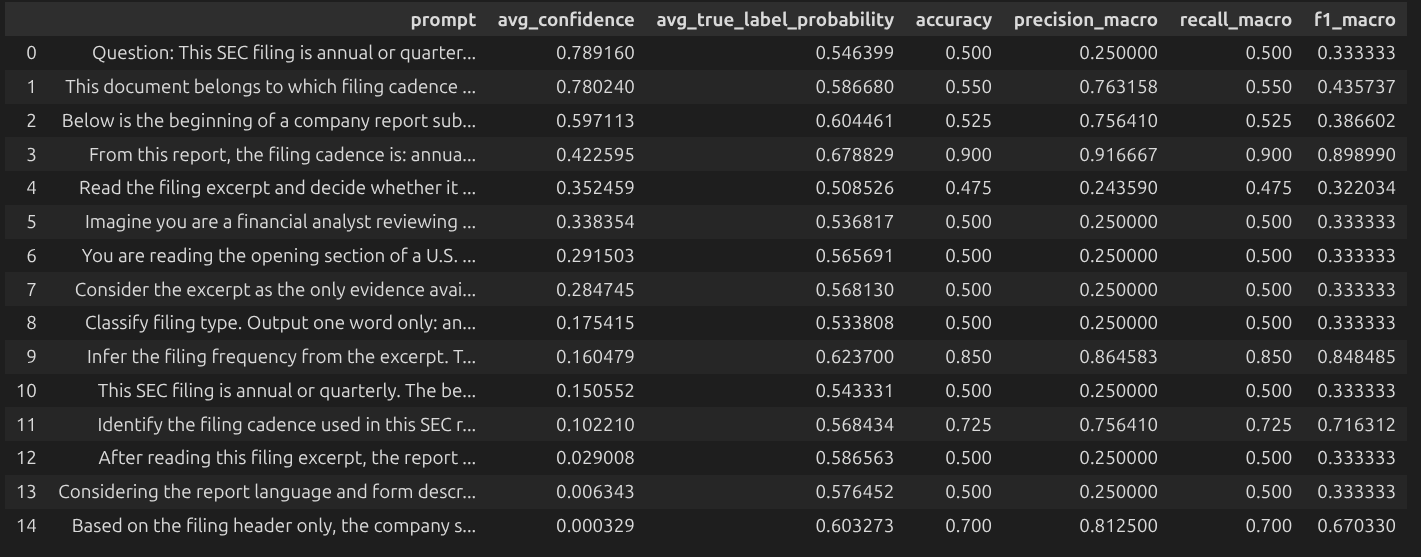

In [8]:
results_df = results_df.sort_values(["f1_macro", "avg_confidence"], ascending=[False, False]).reset_index(drop=True)
display(results_df)

,prompt,avg_confidence,avg_true_label_probability,accuracy,precision_macro,recall_macro,f1_macro
0,"From this report, the filing cadence is: annua...",0.422595,0.678829,0.900,0.916667,0.900,0.898990
1,Infer the filing frequency from the excerpt. T...,0.160479,0.623700,0.850,0.864583,0.850,0.848485
2,Identify the filing cadence used in this SEC r...,0.102210,0.568434,0.725,0.756410,0.725,0.716312
3,"Based on the filing header only, the company s...",0.000329,0.603273,0.700,0.812500,0.700,0.670330
4,This document belongs to which filing cadence ...,0.780240,0.586680,0.550,0.763158,0.550,0.435737
5,Below is the beginning of a company report sub...,0.597113,0.604461,0.525,0.756410,0.525,0.386602
6,Question: This SEC filing is annual or quarter...,0.789160,0.546399,0.500,0.250000,0.500,0.333333
7,Imagine you are a financial analyst reviewing ...,0.338354,0.536817,0.500,0.250000,0.500,0.333333
8,You are reading the opening section of a U.S. ...,0.291503,0.565691,0.500,0.250000,0.500,0.333333
9,Consider the excerpt as the only evidence avai...,0.284745,0.568130,0.500,0.250000,0.500,0.333333


In [9]:
top_3_prompts = results_df.head(3).copy()
display(top_3_prompts[["prompt", "avg_confidence", "precision_macro", "recall_macro", "f1_macro", "accuracy"]])

for idx, row in top_3_prompts.iterrows():
    print(f"\nTop {idx + 1} prompt")
    print(row["prompt"])
    print(
        {
            "avg_confidence": row["avg_confidence"],
            "precision_macro": row["precision_macro"],
            "recall_macro": row["recall_macro"],
            "f1_macro": row["f1_macro"],
            "accuracy": row["accuracy"],
        }
    )

,prompt,avg_confidence,precision_macro,recall_macro,f1_macro,accuracy
0,"From this report, the filing cadence is: annua...",0.422595,0.916667,0.900,0.898990,0.900
1,Infer the filing frequency from the excerpt. T...,0.160479,0.864583,0.850,0.848485,0.850
2,Identify the filing cadence used in this SEC r...,0.102210,0.756410,0.725,0.716312,0.725



Top 1 prompt
From this report, the filing cadence is: annual or quarterly? It is
{'avg_confidence': 0.4225950241088867, 'precision_macro': 0.9166666666666667, 'recall_macro': 0.9, 'f1_macro': 0.898989898989899, 'accuracy': 0.9}

Top 2 prompt
Infer the filing frequency from the excerpt. The correct category is
{'avg_confidence': 0.16047939658164978, 'precision_macro': 0.8645833333333333, 'recall_macro': 0.85, 'f1_macro': 0.8484848484848485, 'accuracy': 0.85}

Top 3 prompt
Identify the filing cadence used in this SEC report. It should be labeled as
{'avg_confidence': 0.10221004486083984, 'precision_macro': 0.7564102564102564, 'recall_macro': 0.7250000000000001, 'f1_macro': 0.7163120567375887, 'accuracy': 0.725}
